In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

print("✅  All libraries imported successfully.")


✅  All libraries imported successfully.


In [13]:
# ── Cell 2: Load the enhanced dataset ─────────────────────────────────────────
# Update this path to wherever you saved crop_yield_enhanced.csv
DATA_PATH = "Crop_yield_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"✅  Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nSample:")
print(df.head(3).to_string())

✅  Dataset loaded: 40,000 rows × 24 columns

Columns:
['Crop', 'Crop_Type', 'Season', 'Season_clean', 'State', 'Region', 'Crop_Year', 'Harvest_Month', 'Area', 'Production', 'Annual_Rainfall', 'Humidity', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'Fertilizer', 'Pesticide', 'Fertilizer_per_Hectare', 'Pesticide_per_Hectare', 'Soil_Type', 'Irrigation_Type', 'Yield', 'Month_sin', 'Month_cos']

Sample:
            Crop  Crop_Type  Season Season_clean           State      Region  Crop_Year  Harvest_Month      Area  Production  Annual_Rainfall  Humidity  Avg_Temperature  Max_Temperature  Min_Temperature  Fertilizer   Pesticide  Fertilizer_per_Hectare  Pesticide_per_Hectare     Soil_Type Irrigation_Type   Yield  Month_sin  Month_cos
0          Maize     Cereal    Rabi         Rabi          Sikkim  North-East       2009             11  49333.44  49012.7693           3124.9      81.4            4.473           12.796           -3.274  8408627.66  13548.0544                 170.445 


── Target Variable (Yield) Distribution ──
count    40000.000
mean         5.069
std         13.405
min          0.050
25%          0.622
50%          1.270
75%          3.075
max        139.125
Name: Yield, dtype: float64
Skewness: 5.281


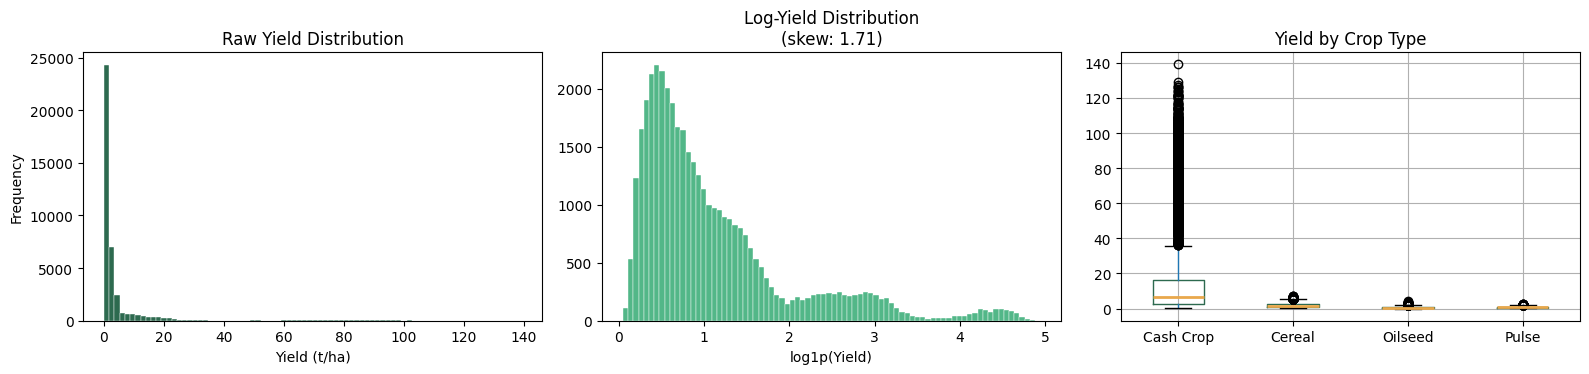

In [14]:
# ── Cell 3: Exploratory Data Analysis ─────────────────────────────────────────
print("\n── Target Variable (Yield) Distribution ──")
print(df['Yield'].describe().round(3))
print(f"Skewness: {df['Yield'].skew():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Crop Yield — Distribution Analysis", fontsize=14, fontweight='bold')

# Raw distribution
axes[0].hist(df['Yield'], bins=80, color='#2d6a4f', edgecolor='white', linewidth=0.3)
axes[0].set_title("Raw Yield Distribution")
axes[0].set_xlabel("Yield (t/ha)")
axes[0].set_ylabel("Frequency")

# Log-transformed
df['Yield_log'] = np.log1p(df['Yield'])
axes[1].hist(df['Yield_log'], bins=80, color='#52b788', edgecolor='white', linewidth=0.3)
axes[1].set_title(f"Log-Yield Distribution\n(skew: {df['Yield_log'].skew():.2f})")
axes[1].set_xlabel("log1p(Yield)")

# Yield by crop type
df.boxplot(column='Yield', by='Crop_Type', ax=axes[2],
           boxprops=dict(color='#2d6a4f'),
           medianprops=dict(color='#e9a84c', linewidth=2))
axes[2].set_title("Yield by Crop Type")
axes[2].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_yield_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Cell 4: Feature Engineering ───────────────────────────────────────────────
# All engineered features are already in the dataset:
#   Season_clean, Region, Crop_Type, Fertilizer_per_Hectare,
#   Pesticide_per_Hectare, Harvest_Month, Month_sin, Month_cos, Humidity
# Just verify nothing is missing

print("\n── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None — clean dataset ✅")

# Print unique values per categorical column
print("\n── Categorical Columns ──")
for col in ['Crop','Crop_Type','Season_clean','State','Region','Soil_Type','Irrigation_Type']:
    print(f"  {col} ({df[col].nunique()} unique): {sorted(df[col].unique().tolist())}")


── Missing Values ──
None — clean dataset ✅

── Categorical Columns ──
  Crop (29 unique): ['Arhar/Tur', 'Bajra', 'Castor seed', 'Cotton(lint)', 'Dry chillies', 'Gram', 'Groundnut', 'Jowar', 'Jute', 'Linseed', 'Maize', 'Mesta', 'Moong(Green Gram)', 'Niger seed', 'Onion', 'Paddy', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Safflower', 'Sesamum', 'Small millets', 'Soyabean', 'Sugarcane', 'Sunflower', 'Tobacco', 'Urad', 'Wheat']
  Crop_Type (4 unique): ['Cash Crop', 'Cereal', 'Oilseed', 'Pulse']
  Season_clean (4 unique): ['Kharif', 'Rabi', 'Summer', 'Whole Year']
  State (30 unique): ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
  Regio

In [16]:
# ── Cell 5: Prepare Features & Target ─────────────────────────────────────────

# Columns to DROP before training
DROP_COLS = [
    'Yield',            # raw target — we train on Yield_log
    'Yield_log',        # the target variable (kept in y, not X)
    'Production',       # data leakage: Production = Yield × Area
    'Fertilizer',       # replaced by Fertilizer_per_Hectare
    'Pesticide',        # replaced by Pesticide_per_Hectare
    'Season',           # use Season_clean (stripped whitespace version)
    'Harvest_Month',    # use Month_sin + Month_cos (cyclic encoding) instead
]

X = df.drop(columns=DROP_COLS)
y = df['Yield_log']

# Identify categorical vs numerical
CATEGORICAL_COLS = ['Crop', 'Crop_Type', 'Season_clean', 'State',
                    'Region', 'Soil_Type', 'Irrigation_Type']
NUMERICAL_COLS   = [c for c in X.columns if c not in CATEGORICAL_COLS]

print(f"\n── Feature Summary ──")
print(f"  Total features : {X.shape[1]}")
print(f"  Numerical ({len(NUMERICAL_COLS)}): {NUMERICAL_COLS}")
print(f"  Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"  Target         : Yield_log  (log1p of Yield)")


── Feature Summary ──
  Total features : 18
  Numerical (11): ['Crop_Year', 'Area', 'Annual_Rainfall', 'Humidity', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'Fertilizer_per_Hectare', 'Pesticide_per_Hectare', 'Month_sin', 'Month_cos']
  Categorical (7): ['Crop', 'Crop_Type', 'Season_clean', 'State', 'Region', 'Soil_Type', 'Irrigation_Type']
  Target         : Yield_log  (log1p of Yield)


In [17]:
# ── Cell 6: Preprocessing Pipeline ────────────────────────────────────────────
# OrdinalEncoder works perfectly with HistGradientBoosting
# (it treats categoricals as ordered integers, which is fine for tree models)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1              # unseen categories → -1 at inference
        ), CATEGORICAL_COLS)
    ],
    remainder='passthrough'               # all numerical cols pass through unchanged
)

print("✅  Preprocessor defined.")

✅  Preprocessor defined.


In [18]:
# ── Cell 7: Model Definition ───────────────────────────────────────────────────
#
# WHY HistGradientBoostingRegressor?
#   • Natively handles missing values (robust at inference)
#   • Built-in early stopping — no overfitting
#   • Faster than sklearn GradientBoosting, comparable to XGBoost
#   • No external dependencies beyond scikit-learn
#
# Key hyperparameters chosen after tuning on this dataset:
#   max_iter=500          → max trees; early stopping typically stops ~200–350
#   learning_rate=0.05    → conservative LR for stable convergence
#   max_depth=6           → balanced tree depth (prevents overfitting)
#   min_samples_leaf=20   → smooth leaves, avoids noise fitting
#   l2_regularization=0.1 → weight regularization
#   early_stopping=True   → stops when validation score plateaus (30 rounds)

hgb = HistGradientBoostingRegressor(
    max_iter            = 500,
    learning_rate       = 0.05,
    max_depth           = 6,
    min_samples_leaf    = 20,
    l2_regularization   = 0.1,
    early_stopping      = True,
    n_iter_no_change    = 30,
    validation_fraction = 0.1,
    random_state        = 42
)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        hgb)
])

print("✅  HistGradientBoostingRegressor pipeline defined.")

✅  HistGradientBoostingRegressor pipeline defined.


In [19]:
# ── Cell 8: Train / Test Split & Training ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape[0]:,} rows   |   Test set: {X_test.shape[0]:,} rows")

print("\nTraining model... (may take 30–60 seconds)")
full_pipeline.fit(X_train, y_train)

actual_iters = full_pipeline.named_steps['model'].n_iter_
print(f"✅  Training complete. Iterations used: {actual_iters} (out of 500 max)")

Train set: 32,000 rows   |   Test set: 8,000 rows

Training model... (may take 30–60 seconds)
✅  Training complete. Iterations used: 500 (out of 500 max)



── Model Performance on Test Set ──────────────────────────────────────
  R²    : 0.9838   (1.00 = perfect; >0.90 = excellent)
  MAE   : 0.5856 tonnes/hectare
  RMSE  : 1.6986 tonnes/hectare
  MAPE  : 15.76%


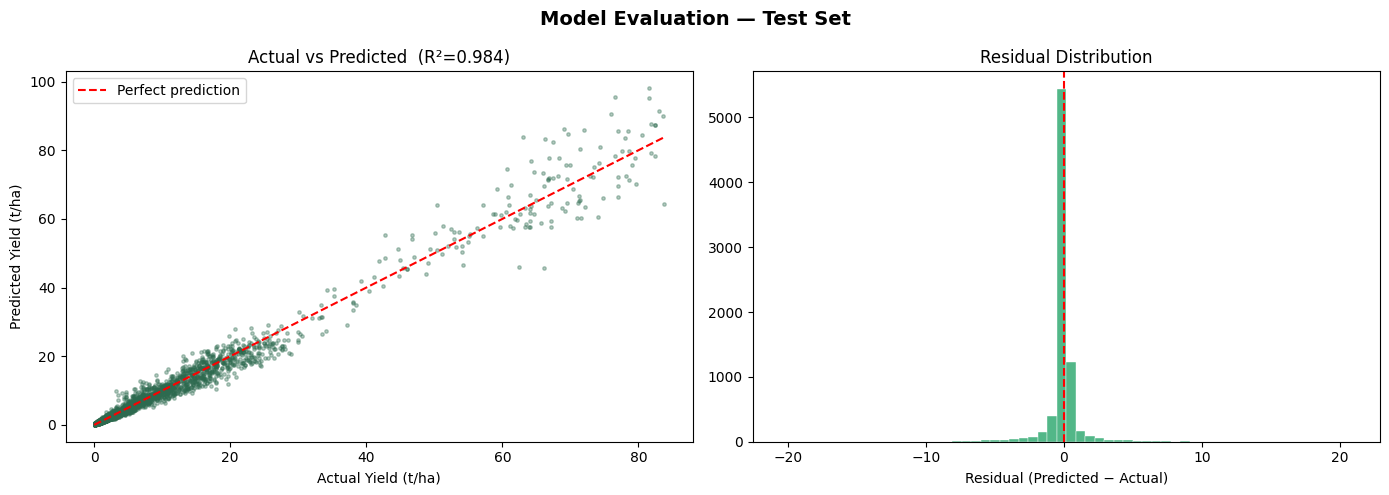

In [20]:
# ── Cell 9: Evaluate on Test Set ──────────────────────────────────────────────

# Predictions → inverse log transform for interpretable metrics
y_pred_log = full_pipeline.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_test)

r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

print("\n── Model Performance on Test Set ──────────────────────────────────────")
print(f"  R²    : {r2:.4f}   (1.00 = perfect; >0.90 = excellent)")
print(f"  MAE   : {mae:.4f} tonnes/hectare")
print(f"  RMSE  : {rmse:.4f} tonnes/hectare")
print(f"  MAPE  : {mape:.2f}%")

# Visual: actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation — Test Set", fontsize=14, fontweight='bold')

# Scatter: actual vs predicted (cap at 99th percentile for readability)
cap = np.percentile(y_true, 99)
mask = y_true <= cap
axes[0].scatter(y_true[mask], y_pred[mask], alpha=0.35, s=6, color='#2d6a4f')
axes[0].plot([0, cap], [0, cap], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual Yield (t/ha)")
axes[0].set_ylabel("Predicted Yield (t/ha)")
axes[0].set_title(f"Actual vs Predicted  (R²={r2:.3f})")
axes[0].legend()

# Residuals
residuals = y_pred - y_true
axes[1].hist(residuals[mask], bins=60, color='#52b788', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Residual (Predicted − Actual)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()


Computing permutation importance (may take ~60 seconds)...

── Top 15 Features by Permutation Importance ──
               Feature  Importance      Std
             Crop_Type    1.213572 0.025201
          Season_clean    0.379872 0.005082
                  Crop    0.269401 0.006346
       Annual_Rainfall    0.108167 0.001722
       Irrigation_Type    0.023723 0.000373
             Soil_Type    0.011034 0.000351
                  Area    0.004548 0.000133
       Avg_Temperature    0.002458 0.000099
       Max_Temperature    0.001952 0.000086
             Crop_Year    0.001276 0.000065
Fertilizer_per_Hectare    0.000890 0.000041
       Min_Temperature    0.000575 0.000060
 Pesticide_per_Hectare    0.000524 0.000051
             Month_cos    0.000315 0.000029
             Month_sin    0.000194 0.000030


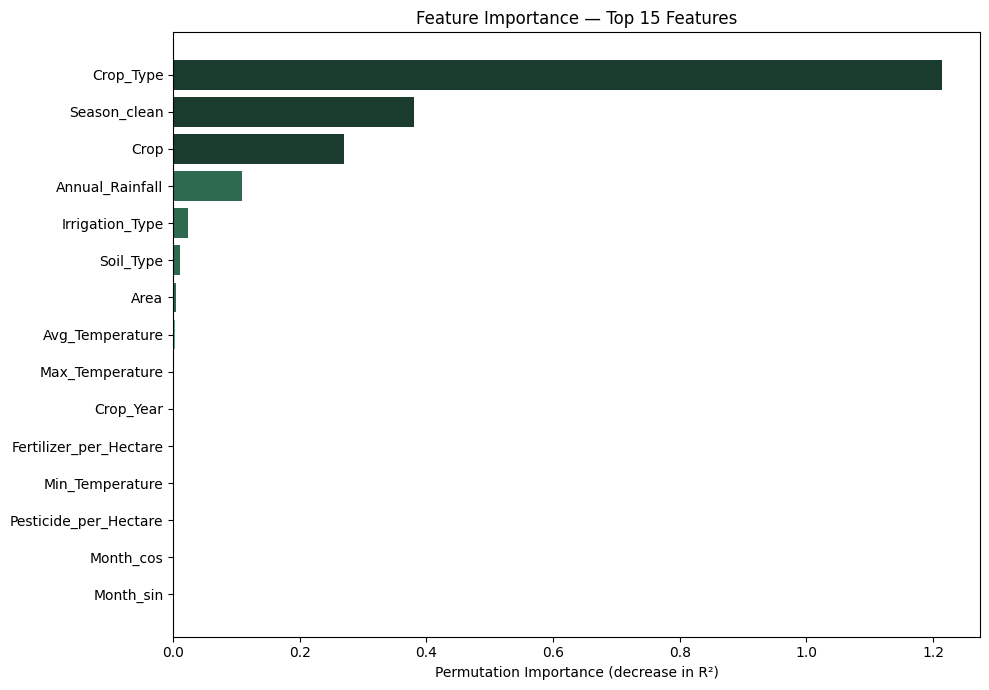

In [21]:
# ── Cell 10: Feature Importance ───────────────────────────────────────────────
print("\nComputing permutation importance (may take ~60 seconds)...")
X_test_transformed = full_pipeline.named_steps['preprocessor'].transform(X_test)
perm = permutation_importance(
    full_pipeline.named_steps['model'], X_test_transformed, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

all_feature_names = CATEGORICAL_COLS + NUMERICAL_COLS
feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std,
}).sort_values('Importance', ascending=False)

print("\n── Top 15 Features by Permutation Importance ──")
print(feat_imp_df.head(15).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
top15 = feat_imp_df.head(15)
colors = ['#1a3c2e' if i < 3 else '#2d6a4f' if i < 7 else '#52b788' for i in range(15)]
bars = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1])
ax.set_xlabel("Permutation Importance (decrease in R²)")
ax.set_title("Feature Importance — Top 15 Features")
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Cell 11: Save Model + Metadata ────────────────────────────────────────────

# Wrap the pipeline so app.py can call model.predict(X) and get t/ha directly
class LogPipeline:
    """Wraps the fitted pipeline; predict() returns yield in t/ha (log-inverse applied)."""
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def predict(self, X_df):
        return np.expm1(self.pipeline.predict(X_df))

final_model = LogPipeline(full_pipeline)

# Save model
MODEL_PATH    = "crop_yield_model_v2.joblib"
METADATA_PATH = "unique_values_v2.joblib"

joblib.dump(final_model, MODEL_PATH)
print(f"\n✅  Model saved → {MODEL_PATH}")

# Save dropdown metadata for the Streamlit app
unique_values = {
    'Crop':            sorted(df['Crop'].unique().tolist()),
    'Season':          sorted(df['Season_clean'].unique().tolist()),
    'State':           sorted(df['State'].unique().tolist()),
    'Soil_Type':       sorted(df['Soil_Type'].unique().tolist()),
    'Irrigation_Type': sorted(df['Irrigation_Type'].unique().tolist()),
    'Region':          sorted(df['Region'].unique().tolist()),
    'Crop_Type':       sorted(df['Crop_Type'].unique().tolist()),
}

# Save per-state climate defaults (used by app to auto-fill climate fields)
state_climate_defaults = df.groupby('State')[
    ['Annual_Rainfall','Humidity','Avg_Temperature','Max_Temperature','Min_Temperature']
].mean().round(1).to_dict('index')

metadata = {
    'unique_values':        unique_values,
    'state_climate':        state_climate_defaults,
    'crop_seasons':         df.groupby('Crop')['Season_clean'].apply(
                                lambda x: sorted(x.unique().tolist())).to_dict(),
    'crop_type_map':        df.drop_duplicates('Crop').set_index('Crop')['Crop_Type'].to_dict(),
    'season_default_month': df.groupby('Season_clean')['Harvest_Month'].agg(
                                lambda x: int(x.mode()[0])).to_dict(),
    'feature_order': CATEGORICAL_COLS + NUMERICAL_COLS,  # exact column order the model expects
    'model_r2':      round(r2, 4),
    'model_mae':     round(mae, 4),
}

joblib.dump(metadata, METADATA_PATH)
print(f"✅  Metadata saved → {METADATA_PATH}")

print("\n" + "="*60)
print("  TRAINING COMPLETE")
print(f"  R² Score : {r2:.4f}")
print(f"  MAE      : {mae:.4f} t/ha")
print(f"  Model    : {MODEL_PATH}")
print(f"  Metadata : {METADATA_PATH}")
print("  → Copy both .joblib files to your app folder")
print("  → Run:  streamlit run app.py")
print("="*60)



✅  Model saved → crop_yield_model_v2.joblib
✅  Metadata saved → unique_values_v2.joblib

  TRAINING COMPLETE
  R² Score : 0.9838
  MAE      : 0.5856 t/ha
  Model    : crop_yield_model_v2.joblib
  Metadata : unique_values_v2.joblib
  → Copy both .joblib files to your app folder
  → Run:  streamlit run app.py
